# Predicción W/L con ROLL10

Objetivo: estimar la probabilidad de victoria/derrota (Win/Loss) en la NBA utilizando únicamente métricas históricas **ROLL10** y respetando un corte temporal configurable por la persona usuaria.

## Configuración general

Importamos las dependencias necesarias y fijamos estilos básicos para las gráficas.

In [16]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.calibration import CalibrationDisplay

import ipywidgets as widgets
from IPython.display import display, Markdown

import platform
import sys
import sklearn
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## Carga y limpieza

Se lee el gamelog agregado por equipo/partido, se generan las columnas necesarias y se filtran únicamente los 30 equipos con mayor número de registros (para evitar ruido de otras ligas).

In [17]:
DATA_PATH = "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/teamgamelogs_by_game.parquet"
RANDOM_STATE = 42
MIN_HISTORY_GAMES = 10

def load_and_clean_data(data_path: str) -> pd.DataFrame:
    path = Path(data_path)
    if not path.exists():
        raise FileNotFoundError(f"No se encontró el archivo en {path}. Ajusta DATA_PATH si es necesario.")

    df = pd.read_parquet(path)

    required_columns = {"GAME_DATE", "WL", "TEAM_ID", "TEAM_ABBREVIATION", "GAME_ID"}
    missing = required_columns.difference(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas obligatorias en el parquet: {sorted(missing)}")

    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"], errors="coerce")

    df["WL"] = df["WL"].astype(str).str.upper().str.strip()
    df["WL_NUM"] = df["WL"].map({"W": 1, "L": 0})
    df.loc[~df["WL"].isin(["W", "L"]), "WL_NUM"] = np.nan

    top_teams = df["TEAM_ID"].value_counts().nlargest(30).index
    df = df[df["TEAM_ID"].isin(top_teams)].copy()

    df = df.sort_values(["TEAM_ID", "GAME_DATE", "GAME_ID"]).reset_index(drop=True)
    return df


df = load_and_clean_data(DATA_PATH)
print(f"Registros tras limpieza: {len(df):,}")
print(f"Equipos únicos: {df['TEAM_ABBREVIATION'].nunique()}")
print(f"Rango de fechas: {df['GAME_DATE'].min().date()} → {df['GAME_DATE'].max().date()}")
df.head(3)


Registros tras limpieza: 2,639
Equipos únicos: 30
Rango de fechas: 2024-07-06 → 2025-04-13


,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,ROLL10_PCT_PTS_OFF_TOV,ROLL10_PCT_PTS_PAINT,ROLL10_PCT_REB,ROLL10_PCT_STL,ROLL10_PCT_TOV,ROLL10_PCT_UAST_2PM,ROLL10_PCT_UAST_3PM,ROLL10_PCT_UAST_FGM,ROLL10_PLUS_MINUS,WL_NUM
0,2024,1610612737,ATL,Atlanta Hawks,1522400006,2024-07-12,ATL @ WAS,L,40.0,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2024,1610612737,ATL,Atlanta Hawks,1522400021,2024-07-14,ATL vs. SAS,L,40.0,25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.0,0.0
2,2024,1610612737,ATL,Atlanta Hawks,1522400044,2024-07-17,ATL vs. LAL,L,40.0,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.5,0.0


## Ingeniería de features (solo ROLL10)

Se seleccionan únicamente las columnas que comienzan con `ROLL10_`, se infiere la condición de local/visitante y se construye un dataset a nivel partido con features diferenciales (local − visitante).

In [18]:
def infer_home_indicator(df: pd.DataFrame) -> pd.Series:
    if "HOME_TEAM_ID" in df.columns:
        return df["TEAM_ID"] == df["HOME_TEAM_ID"]

    matchup_col = next((col for col in ["MATCHUP", "GAME_MATCHUP"] if col in df.columns), None)
    if matchup_col is not None:
        matchup_series = df[matchup_col].astype(str).str.upper()
        return matchup_series.str.contains(" VS", na=False)

    for candidate in ["HOME_AWAY", "HOME_GAME", "IS_HOME"]:
        if candidate in df.columns:
            col = df[candidate]
            if candidate == "IS_HOME":
                return col.astype(bool)
            col = col.astype(str).str.upper()
            return col.isin(["HOME", "H", "1", "TRUE", "LOCAL"])

    raise ValueError("No se pudo inferir la localía (home/away) con las columnas disponibles.")


def select_roll10_features(df: pd.DataFrame) -> list:
    roll_cols = [c for c in df.columns if c.startswith("ROLL10_")]
    cleaned = []
    excluded_keywords = {"_RANK"}
    explicit_exclusions = {"ROLL10_WL", "ROLL10_WL_NUM"}
    for col in roll_cols:
        if any(keyword in col.upper() for keyword in excluded_keywords):
            continue
        if col in explicit_exclusions:
            continue
        cleaned.append(col)
    return sorted(cleaned)


def build_matchup_dataset(df: pd.DataFrame, feature_cols: list, target_col: str):
    df = df.copy()
    df["IS_HOME"] = infer_home_indicator(df)

    if "GAME_ID" not in df.columns:
        raise KeyError("Se requiere la columna GAME_ID para emparejar los registros.")

    base_cols = ["GAME_ID", "GAME_DATE", "TEAM_ID", "TEAM_ABBREVIATION"]
    missing_base = [col for col in base_cols if col not in df.columns]
    if missing_base:
        raise KeyError(f"Faltan columnas base para emparejar partidos: {missing_base}")

    home_df = df[df["IS_HOME"]].copy()
    away_df = df[~df["IS_HOME"]].copy()

    required_home_cols = base_cols + [target_col] + feature_cols
    required_away_cols = base_cols + feature_cols

    missing_home = [col for col in required_home_cols if col not in home_df.columns]
    missing_away = [col for col in required_away_cols if col not in away_df.columns]
    if missing_home or missing_away:
        raise KeyError(f"Faltan columnas necesarias. Home: {missing_home}. Away: {missing_away}.")

    home_df = home_df[required_home_cols]
    away_df = away_df[required_away_cols]

    home_df = home_df.rename(columns={
        "GAME_DATE": "GAME_DATE_HOME",
        "TEAM_ID": "HOME_TEAM_ID",
        "TEAM_ABBREVIATION": "HOME_TEAM_ABBREVIATION",
        target_col: "HOME_WL_NUM"
    })
    away_df = away_df.rename(columns={
        "GAME_DATE": "GAME_DATE_AWAY",
        "TEAM_ID": "AWAY_TEAM_ID",
        "TEAM_ABBREVIATION": "AWAY_TEAM_ABBREVIATION"
    })

    feature_home_cols = {col: f"{col}_HOME" for col in feature_cols}
    feature_away_cols = {col: f"{col}_AWAY" for col in feature_cols}

    home_df = home_df.rename(columns=feature_home_cols)
    away_df = away_df.rename(columns=feature_away_cols)

    home_df = home_df.set_index("GAME_ID")
    away_df = away_df.set_index("GAME_ID")

    merged = home_df.join(away_df, how="inner")
    if len(merged) != len(home_df) or len(merged) != len(away_df):
        print(f"⚠️ Partidos descartados por falta de registros de alguna de las partes: {len(home_df) - len(merged)} home | {len(away_df) - len(merged)} away")
    merged = merged.reset_index()

    if merged["GAME_ID"].duplicated().any():
        raise ValueError("Se encontraron GAME_ID duplicados tras el emparejamiento. Revisa el dataset base.")

    diff_feature_cols = [f"{col}_DIFF" for col in feature_cols]
    home_feature_array = merged[[f"{col}_HOME" for col in feature_cols]].to_numpy()
    away_feature_array = merged[[f"{col}_AWAY" for col in feature_cols]].to_numpy()
    diff_array = home_feature_array - away_feature_array
    diff_df = pd.DataFrame(diff_array, columns=diff_feature_cols)

    matchup_df = pd.concat(
        [
            merged[["GAME_ID", "GAME_DATE_HOME", "HOME_TEAM_ID", "HOME_TEAM_ABBREVIATION",
                    "AWAY_TEAM_ID", "AWAY_TEAM_ABBREVIATION", "HOME_WL_NUM"]],
            diff_df
        ],
        axis=1
    )
    matchup_df = matchup_df.rename(columns={
        "GAME_DATE_HOME": "GAME_DATE",
        "HOME_WL_NUM": target_col
    })
    matchup_df["GAME_DATE"] = pd.to_datetime(matchup_df["GAME_DATE"], errors="coerce")
    matchup_df = matchup_df.sort_values("GAME_DATE").reset_index(drop=True)
    return matchup_df, diff_feature_cols


feature_cols = select_roll10_features(df)
matchup_df, diff_feature_cols = build_matchup_dataset(df, feature_cols, "WL_NUM")
print(f"Partidos emparejados con features diferenciales: {len(matchup_df):,}")
print(f"Total de columnas ROLL10 disponibles: {len(diff_feature_cols)}")

model_df = matchup_df.copy()
rows_before = len(model_df)
model_df = model_df.dropna(subset=["WL_NUM"] + diff_feature_cols)
rows_after = len(model_df)
print(f"Filas eliminadas por nulos en target/features: {rows_before - rows_after}")
print(f"Filas finales para modelado: {rows_after}")
print(f"¿Todas las columnas comienzan por 'ROLL10_'?: {all(col.startswith('ROLL10_') for col in diff_feature_cols)}")
model_df.head(3)


⚠️ Partidos descartados por falta de registros de alguna de las partes: 2 home | 15 away
Partidos emparejados con features diferenciales: 1,311
Total de columnas ROLL10 disponibles: 75
Filas eliminadas por nulos en target/features: 102
Filas finales para modelado: 1209
¿Todas las columnas comienzan por 'ROLL10_'?: True


,GAME_ID,GAME_DATE,HOME_TEAM_ID,HOME_TEAM_ABBREVIATION,AWAY_TEAM_ID,AWAY_TEAM_ABBREVIATION,WL_NUM,ROLL10_AST_DIFF,ROLL10_AST_PCT_DIFF,ROLL10_AST_TOV_DIFF,...,ROLL10_PTS_FB_DIFF,ROLL10_PTS_OFF_TOV_DIFF,ROLL10_PTS_PAINT_DIFF,ROLL10_REB_DIFF,ROLL10_REB_PCT_DIFF,ROLL10_STL_DIFF,ROLL10_TM_TOV_PCT_DIFF,ROLL10_TOV_DIFF,ROLL10_TS_PCT_DIFF,ROLL10_USG_PCT_DIFF
102,0022400081,2024-10-25,1610612752,NYK,1610612754,IND,1.0,-2.666667,-0.07100,0.11167,...,-0.91667,-0.83333,-0.83333,-3.000000,-0.00409,-2.000000,-2.15834,-4.833333,-0.09442,0.00583
103,0022400080,2024-10-25,1610612739,CLE,1610612765,DET,1.0,2.000000,-0.00868,-0.17308,...,0.23077,0.90769,0.23077,-2.500000,0.00143,2.000000,-1.80231,0.333333,0.14038,0.02144
104,0022400084,2024-10-25,1610612762,UTA,1610612744,GSW,0.0,-4.888889,-0.06227,-0.12357,...,-1.18571,-0.27143,1.60000,-4.666667,-0.01583,-0.444444,2.21714,2.000000,-0.07920,-0.01523


## Split temporal por fecha

El usuario define una fecha de corte. Todos los partidos anteriores se usan para entrenamiento y los posteriores/iguales para test. Se muestran los tamaños de cada split y la distribución de victorias/derrotas.

In [19]:
cutoff_input = widgets.Text(
    value="2025-01-15",
    description="Fecha corte:",
    placeholder="YYYY-MM-DD",
    layout=widgets.Layout(width="250px")
)

display(Markdown("Selecciona la fecha que separa entrenamiento y test (formato YYYY-MM-DD)."))
display(cutoff_input)


Selecciona la fecha que separa entrenamiento y test (formato YYYY-MM-DD).

Text(value='2025-01-15', description='Fecha corte:', layout=Layout(width='250px'), placeholder='YYYY-MM-DD')

In [20]:
def create_splits(df_model: pd.DataFrame, cutoff_value: str):
    cutoff_dt = pd.to_datetime(cutoff_value)
    if pd.isna(cutoff_dt):
        raise ValueError("La fecha de corte no es válida. Usa el formato YYYY-MM-DD.")

    train_mask = df_model["GAME_DATE"] < cutoff_dt
    test_mask = df_model["GAME_DATE"] >= cutoff_dt

    X_train = df_model.loc[train_mask, diff_feature_cols].copy()
    y_train = df_model.loc[train_mask, "WL_NUM"].astype(int)
    X_test = df_model.loc[test_mask, diff_feature_cols].copy()
    y_test = df_model.loc[test_mask, "WL_NUM"].astype(int)

    if X_train.empty or X_test.empty:
        raise ValueError("El corte seleccionado deja sin datos alguno de los splits. Ajusta la fecha.")

    return cutoff_dt, X_train, X_test, y_train, y_test


def describe_target(y: pd.Series) -> pd.DataFrame:
    counts = y.value_counts().sort_index()
    share = (counts / counts.sum()).rename("ratio")
    summary = pd.concat([counts.rename("count"), share], axis=1)
    summary.index = summary.index.map({0: "L", 1: "W"})
    return summary


cutoff_date, X_train, X_test, y_train, y_test = create_splits(model_df, cutoff_input.value)

print(f"Fecha de corte: {cutoff_date.date()}")
print(f"Partidos en train: {len(X_train):,}")
print(f"Partidos en test: {len(X_test):,}")

summary = pd.concat({
    "Train": describe_target(y_train),
    "Test": describe_target(y_test)
}, axis=1)
display(summary)


Fecha de corte: 2025-01-15
Partidos en train: 567
Partidos en test: 642


Train            Test          
       count     ratio count     ratio
WL_NUM                                
L        254  0.447972   293  0.456386
W        313  0.552028   349  0.543614

## Modelo y entrenamiento

Se entrenan dos modelos (Logistic Regression con `StandardScaler` y Gradient Boosting) usando únicamente features ROLL10 diferenciales.

In [21]:
trained_models: dict[str, object] = {}
results: dict[str, dict[str, np.ndarray]] = {}

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver="liblinear",
        max_iter=1000
    ))
])

lr_pipeline.fit(X_train, y_train)
trained_models["Logistic Regression"] = lr_pipeline
results["Logistic Regression"] = {
    "y_pred": lr_pipeline.predict(X_test),
    "y_proba": lr_pipeline.predict_proba(X_test)[:, 1]
}


gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_model.fit(X_train, y_train)
trained_models["Gradient Boosting"] = gb_model
results["Gradient Boosting"] = {
    "y_pred": gb_model.predict(X_test),
    "y_proba": gb_model.predict_proba(X_test)[:, 1]
}

print("Modelos entrenados correctamente.")


Modelos entrenados correctamente.


## Evaluación (métricas + gráficas)

Se calculan métricas clásicas (Accuracy, Balanced Accuracy, ROC-AUC, PR-AUC, Brier score y Log Loss) y se visualizan matrices de confusión, curvas ROC/PR, calibración y la importancia de variables.

In [22]:
def safe_metric(metric_fn, *args, **kwargs):
    try:
        return metric_fn(*args, **kwargs)
    except ValueError:
        return np.nan


def evaluate_models(results_dict: dict, y_true: pd.Series) -> pd.DataFrame:
    rows = []
    for name, result in results_dict.items():
        y_pred = result["y_pred"]
        y_proba = result["y_proba"]
        row = {
            "Modelo": name,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Balanced Accuracy": safe_metric(balanced_accuracy_score, y_true, y_pred),
            "ROC-AUC": safe_metric(roc_auc_score, y_true, y_proba),
            "PR-AUC": safe_metric(average_precision_score, y_true, y_proba),
            "Brier": safe_metric(brier_score_loss, y_true, y_proba),
            "Log Loss": safe_metric(log_loss, y_true, np.vstack([1 - y_proba, y_proba]).T, labels=[0, 1])
        }
        rows.append(row)
    metrics_df = pd.DataFrame(rows).set_index("Modelo")
    return metrics_df


metrics_df = evaluate_models(results, y_test)
display(metrics_df.round(4))


,Accuracy,Balanced Accuracy,ROC-AUC,PR-AUC,Brier,Log Loss
Modelo,,,,,,
Logistic Regression,0.5576,0.5548,0.6133,0.6519,0.2591,0.7282
Gradient Boosting,0.5981,0.5918,0.6400,0.6561,0.2544,0.7366


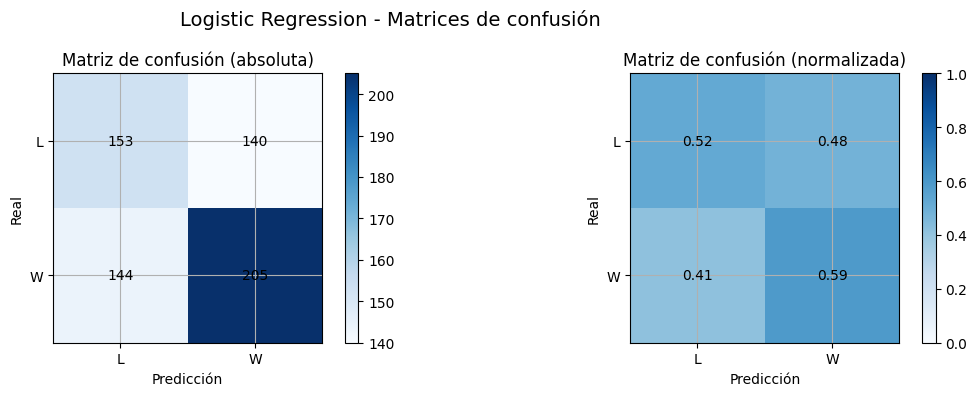

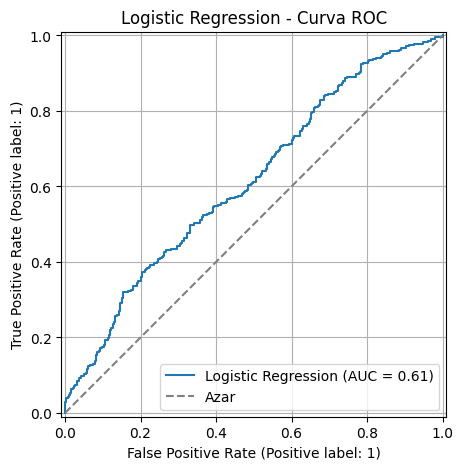

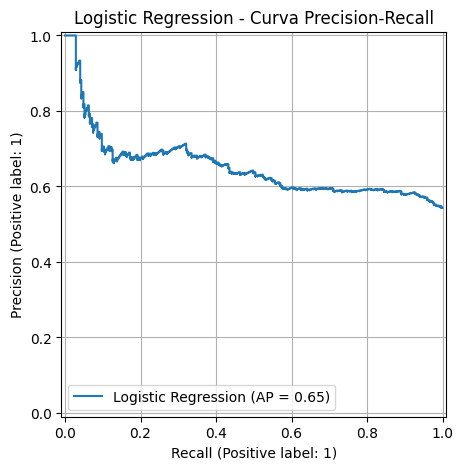

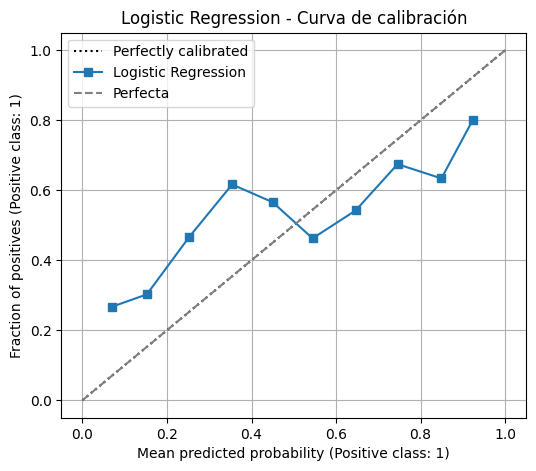

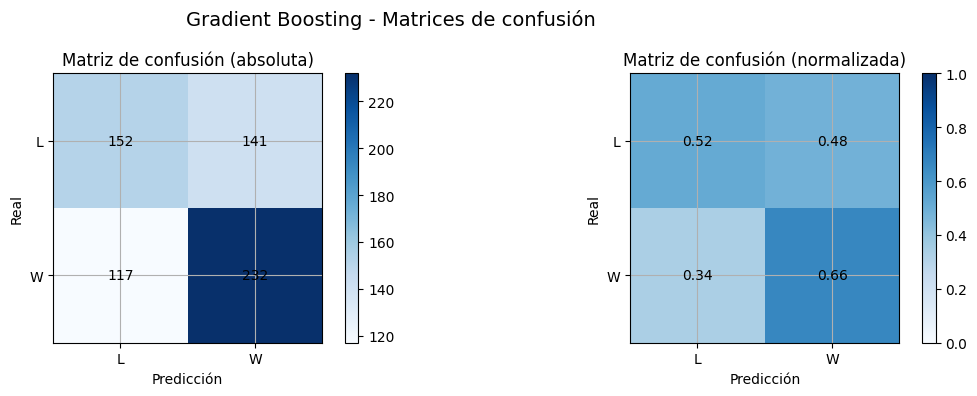

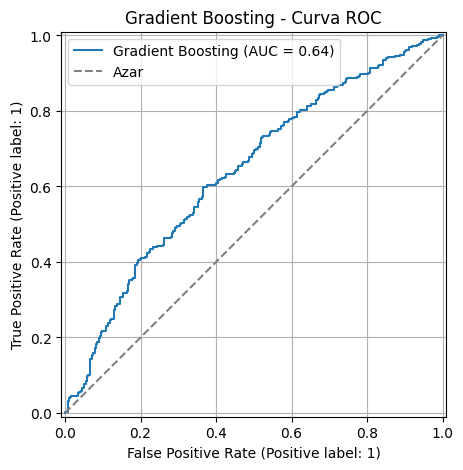

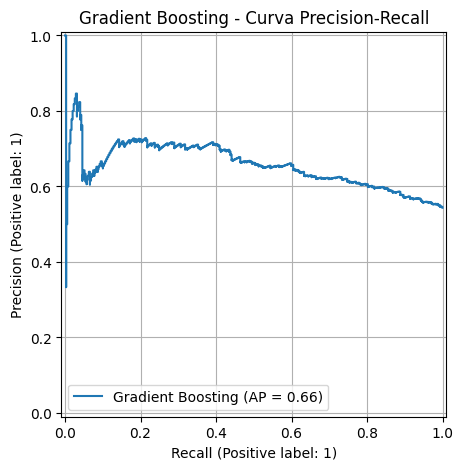

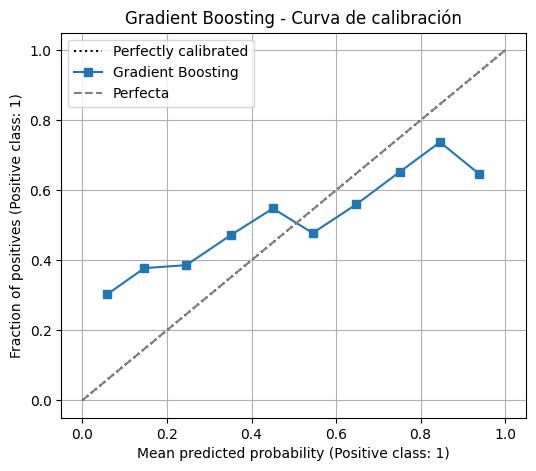

In [23]:
def plot_confusion_matrices(y_true, y_pred, model_name):
    labels = [0, 1]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm_abs = confusion_matrix(y_true, y_pred, labels=labels)
    im0 = axes[0].imshow(cm_abs, cmap="Blues")
    for i in range(len(labels)):
        for j in range(len(labels)):
            axes[0].text(j, i, int(cm_abs[i, j]), ha="center", va="center", color="black")
    axes[0].set_title("Matriz de confusión (absoluta)")
    axes[0].set_xlabel("Predicción")
    axes[0].set_ylabel("Real")
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(["L", "W"])
    axes[0].set_yticks([0, 1])
    axes[0].set_yticklabels(["L", "W"])
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    im1 = axes[1].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(len(labels)):
        for j in range(len(labels)):
            axes[1].text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", color="black")
    axes[1].set_title("Matriz de confusión (normalizada)")
    axes[1].set_xlabel("Predicción")
    axes[1].set_ylabel("Real")
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(["L", "W"])
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(["L", "W"])
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    fig.suptitle(f"{model_name} - Matrices de confusión", fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_roc_pr_curves(y_true, y_proba, model_name):
    if len(np.unique(y_true)) < 2:
        print(f"No es posible trazar curvas ROC/PR para {model_name} (solo hay una clase en y_test).")
        return

    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_true, y_proba, ax=ax, name=model_name)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
    ax.set_title(f"{model_name} - Curva ROC")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_true, y_proba, ax=ax, name=model_name)
    ax.set_title(f"{model_name} - Curva Precision-Recall")
    plt.show()


def plot_calibration_curve(y_true, y_proba, model_name, n_bins=10):
    fig, ax = plt.subplots(figsize=(6, 5))
    CalibrationDisplay.from_predictions(y_true, y_proba, ax=ax, n_bins=n_bins, name=model_name)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfecta")
    ax.set_title(f"{model_name} - Curva de calibración")
    ax.legend()
    plt.show()


for model_name, result in results.items():
    plot_confusion_matrices(y_test, result["y_pred"], model_name)
    plot_roc_pr_curves(y_test, result["y_proba"], model_name)
    plot_calibration_curve(y_test, result["y_proba"], model_name)


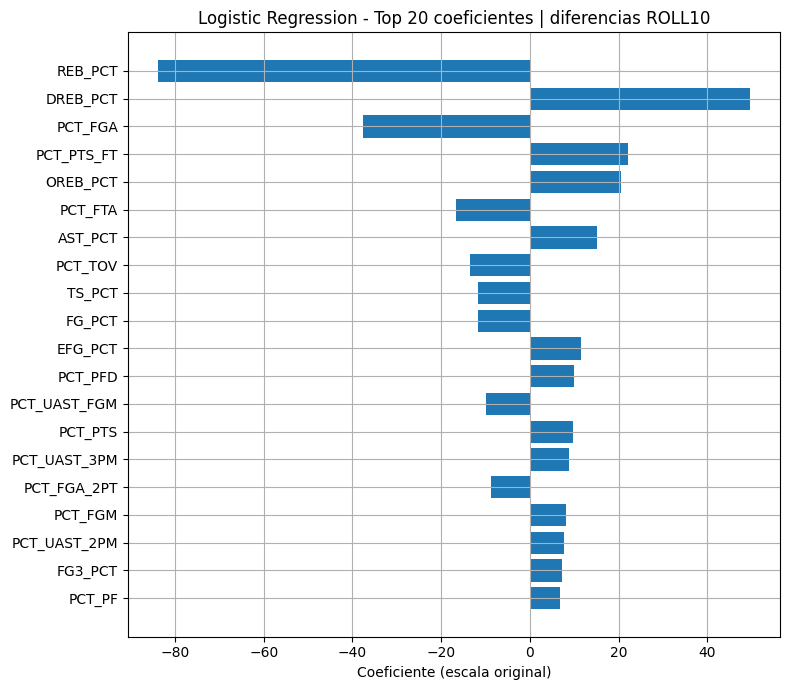

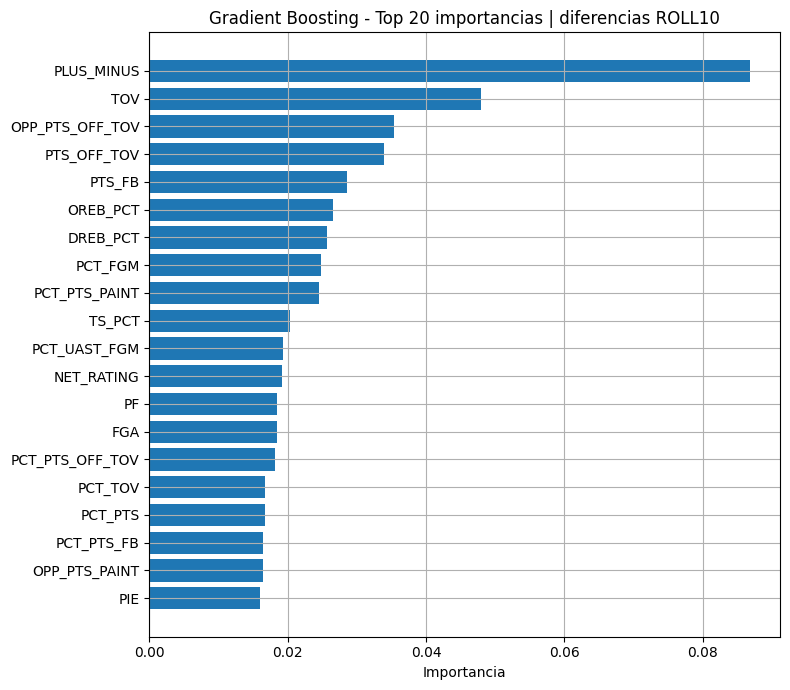

In [24]:
def plot_top_coefficients(pipeline: Pipeline, feature_names: list, top_n: int = 20):
    scaler = pipeline.named_steps["scaler"]
    clf = pipeline.named_steps["clf"]
    coef = clf.coef_[0] / scaler.scale_
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coef,
        "abs_coef": np.abs(coef)
    }).sort_values("abs_coef", ascending=False).head(top_n)
    pretty = coef_df["feature"].str.replace("ROLL10_", "", regex=False).str.replace("_DIFF", "", regex=False)

    fig, ax = plt.subplots(figsize=(8, max(6, top_n * 0.35)))
    ax.barh(pretty.iloc[::-1], coef_df["coef"].iloc[::-1])
    ax.set_xlabel("Coeficiente (escala original)")
    ax.set_title(f"Logistic Regression - Top {top_n} coeficientes | diferencias ROLL10")
    plt.tight_layout()
    plt.show()


def plot_feature_importances(model: GradientBoostingClassifier, feature_names: list, top_n: int = 20):
    importances = model.feature_importances_
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(top_n)
    pretty = imp_df["feature"].str.replace("ROLL10_", "", regex=False).str.replace("_DIFF", "", regex=False)

    fig, ax = plt.subplots(figsize=(8, max(6, top_n * 0.35)))
    ax.barh(pretty.iloc[::-1], imp_df["importance"].iloc[::-1])
    ax.set_xlabel("Importancia")
    ax.set_title(f"Gradient Boosting - Top {top_n} importancias | diferencias ROLL10")
    plt.tight_layout()
    plt.show()


plot_top_coefficients(trained_models["Logistic Regression"], diff_feature_cols, top_n=20)
plot_feature_importances(trained_models["Gradient Boosting"], diff_feature_cols, top_n=20)


## Exploración interactiva (2 equipos y fecha)

Widgets para seleccionar un partido (local, visitante, fecha) y el modelo a usar. El notebook recupera el último registro disponible previo a la fecha para cada equipo, construye las features diferenciales y estima la probabilidad de victoria local. También se listan las 10 variables más influyentes en ese emparejamiento.

In [25]:
available_teams = sorted(df["TEAM_ABBREVIATION"].unique())


def get_latest_team_snapshot(df_source: pd.DataFrame, team_abbr: str, as_of_date: pd.Timestamp):
    team_history = df_source[(df_source["TEAM_ABBREVIATION"] == team_abbr) & (df_source["GAME_DATE"] < as_of_date)].sort_values("GAME_DATE")
    if team_history.empty:
        return None, 0
    latest = team_history.iloc[-1]
    return latest, len(team_history)


def build_diff_features_from_rows(home_row: pd.Series, away_row: pd.Series, base_feature_cols: list) -> pd.Series:
    data = {}
    for col in base_feature_cols:
        data[f"{col}_DIFF"] = home_row[col] - away_row[col]
    return pd.Series(data)


def prepare_match_dataframe(diff_series: pd.Series, feature_names: list) -> pd.DataFrame:
    return pd.DataFrame([diff_series.reindex(feature_names)], columns=feature_names)


def summarize_contributions(model_name: str, model, X_match: pd.DataFrame) -> pd.DataFrame:
    feature_values = X_match.iloc[0].values
    if model_name == "Logistic Regression":
        pipeline: Pipeline = model
        scaler = pipeline.named_steps["scaler"]
        clf = pipeline.named_steps["clf"]
        coef = clf.coef_[0] / scaler.scale_
        contrib = coef * feature_values
        df_summary = pd.DataFrame({
            "feature": diff_feature_cols,
            "valor": feature_values,
            "peso_modelo": coef,
            "contribucion": contrib
        })
    else:
        gb_model: GradientBoostingClassifier = model
        importance = gb_model.feature_importances_
        contrib = feature_values * importance
        df_summary = pd.DataFrame({
            "feature": diff_feature_cols,
            "valor": feature_values,
            "peso_modelo": importance,
            "contribucion": contrib
        })
    df_summary["abs_contribucion"] = df_summary["contribucion"].abs()
    df_summary["feature_pretty"] = df_summary["feature"].str.replace("ROLL10_", "", regex=False).str.replace("_DIFF", "", regex=False)
    df_summary = df_summary.sort_values("abs_contribucion", ascending=False).head(10)
    return df_summary[["feature_pretty", "valor", "peso_modelo", "contribucion"]]


def render_match_prediction(change=None):
    output.clear_output()
    with output:
        try:
            game_date = pd.to_datetime(game_date_widget.value)
        except Exception:
            print("⚠️ Introduce una fecha válida en formato YYYY-MM-DD.")
            return

        home_team = home_team_widget.value
        away_team = away_team_widget.value
        model_name = model_widget.value

        if home_team == away_team:
            print("⚠️ Selecciona equipos distintos para local y visitante.")
            return

        home_snapshot, home_count = get_latest_team_snapshot(df, home_team, game_date)
        away_snapshot, away_count = get_latest_team_snapshot(df, away_team, game_date)

        if home_snapshot is None or away_snapshot is None:
            print("No hay histórico suficiente para construir las features ROLL10 del partido solicitado.")
            print(f"{home_team}: {home_count} registros previos | {away_team}: {away_count} registros previos")
            return

        warnings_msgs = []
        if home_count < MIN_HISTORY_GAMES:
            warnings_msgs.append(f"{home_team}: solo {home_count} partidos previos antes de la fecha seleccionada.")
        if away_count < MIN_HISTORY_GAMES:
            warnings_msgs.append(f"{away_team}: solo {away_count} partidos previos antes de la fecha seleccionada.")

        diff_series = build_diff_features_from_rows(home_snapshot, away_snapshot, feature_cols)
        if diff_series.isna().any():
            missing = diff_series[diff_series.isna()].index.tolist()
            print(f"Las siguientes columnas tienen valores faltantes: {missing}")
            return

        X_match = prepare_match_dataframe(diff_series, diff_feature_cols)
        model = trained_models[model_name]
        proba_home = model.predict_proba(X_match)[0, 1]

        summary = summarize_contributions(model_name, model, X_match)
        summary = summary.rename(columns={
            "feature_pretty": "Feature diferencial (ROLL10)",
            "valor": "Valor home-away",
            "peso_modelo": "Peso modelo",
            "contribucion": "Peso × valor"
        })
        summary = summary.round({"Valor home-away": 4, "Peso modelo": 4, "Peso × valor": 4})

        display(Markdown(f"**Probabilidad estimada de victoria local ({model_name})**: {proba_home:.1%}"))
        display(Markdown(f"Histórico disponible → {home_team}: {home_count} | {away_team}: {away_count}"))
        if warnings_msgs:
            for msg in warnings_msgs:
                display(Markdown(f"- ⚠️ {msg}"))

        display(summary)


def make_default_team(option: str, fallback_index: int = 0) -> str:
    if option in available_teams:
        return option
    if available_teams:
        idx = min(max(fallback_index, 0), len(available_teams) - 1)
        return available_teams[idx]
    raise ValueError("No hay equipos disponibles en el dataset.")


home_team_widget = widgets.Dropdown(options=available_teams, value=make_default_team("BOS"), description="Local:")
away_team_widget = widgets.Dropdown(options=available_teams, value=make_default_team("MIA", 1), description="Visitante:")
model_widget = widgets.ToggleButtons(options=list(trained_models.keys()), description="Modelo:")
game_date_widget = widgets.Text(value="2025-02-20", description="Fecha:")
output = widgets.Output()

for widget_control in [home_team_widget, away_team_widget, model_widget, game_date_widget]:
    widget_control.observe(render_match_prediction, names="value")

controls = widgets.VBox([
    widgets.HBox([home_team_widget, away_team_widget, model_widget]),
    game_date_widget
])

display(controls)
display(output)

render_match_prediction()


Output()

## Diagnósticos y sanity checks

Verificación adicional para asegurar ausencia de fuga de información, reporte de nulos y correlaciones más relevantes en el conjunto de entrenamiento.

In [26]:
leaky_cols = [col for col in diff_feature_cols if col.endswith("_WL") or col.endswith("_WL_NUM")]
print(f"Columnas potencialmente problemáticas dentro de las features: {leaky_cols if leaky_cols else 'ninguna (solo ROLL10 históricos).'}")

null_train_features = int(X_train.isna().sum().sum())
null_test_features = int(X_test.isna().sum().sum())
null_train_target = int(y_train.isna().sum())
null_test_target = int(y_test.isna().sum())
print(f"Nulos → X_train: {null_train_features}, X_test: {null_test_features}, y_train: {null_train_target}, y_test: {null_test_target}")

train_corr = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
correlations = train_corr.corr(numeric_only=True)["WL_NUM"].drop("WL_NUM", errors="ignore")
correlations = correlations.abs().sort_values(ascending=False).head(15)
print("Top 15 correlaciones absolutas con WL_NUM (train):")
display(correlations.to_frame(name="|corr|"))


Columnas potencialmente problemáticas dentro de las features: ninguna (solo ROLL10 históricos).
Nulos → X_train: 0, X_test: 0, y_train: 0, y_test: 0
Top 15 correlaciones absolutas con WL_NUM (train):


,|corr|
ROLL10_PLUS_MINUS_DIFF,0.351752
ROLL10_NET_RATING_DIFF,0.310473
ROLL10_E_NET_RATING_DIFF,0.310473
ROLL10_TOV_DIFF,0.250262
ROLL10_OPP_PTS_OFF_TOV_DIFF,0.248638
ROLL10_DEF_RATING_DIFF,0.243379
ROLL10_E_DEF_RATING_DIFF,0.243379
ROLL10_FGM_DIFF,0.234465
ROLL10_PTS_DIFF,0.233353
ROLL10_FG_PCT_DIFF,0.206710


## Reproducibilidad

Versiones de las librerías clave utilizadas en este notebook.

In [27]:
print(f"Python: {sys.version}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")


Python: 3.13.5 (v3.13.5:6cb20a219a8, Jun 11 2025, 12:23:45) [Clang 16.0.0 (clang-1600.0.26.6)]
pandas: 2.3.2
numpy: 2.3.3
scikit-learn: 1.7.2
matplotlib: 3.10.6
